# Classification with XGBoost


In [4]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

Load, clean train

In [ ]:
# Load and clean dataset
data = pd.read_csv('data/bcn_noise_class_ml_dataset.csv')


In [ ]:
# Feature engineering (combine width and betweenness centrality, create new features based on distances)
data['width_x_betw'] = data['width'] * data['betw_centrality']
data['min_arterial_dist'] = data[['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']].min(axis=1)
data['min_local_road_dist'] = data[['dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street']].min(axis=1)

In [26]:
# Clean dataset
data_clean = data.dropna()
data_clean.reset_index(inplace=True, drop = True)
X = data_clean.drop(columns=['road_id','noise_day','noise_evening', 'noise_night','height','width','road_category','betw_centrality'])  # keep only features

In [27]:
# No need for encoding since all features are numerical
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting
y = np.asarray(data_clean["noise_day"])
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)


(8783, 19)
(8783,)
(2928, 19)


In [28]:
# Train XGBoost model
model = xgb.XGBClassifier()

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))


[0.71428571 0.7097325  0.6943654  0.69305239 0.71412301]
0.9751793236934988
0.7110655737704918


ExAI

Dependance Scatter plots

**What the Plot Shows**
This is a dependence scatter plot:
X-axis: The actual feature value, e.g., the flipper length in millimetres.
Y-axis: The SHAP value for that feature, i.e., how much that flipper length contributes to the prediction for class 0 (e.g., Adelie).
Each dot is an individual prediction/sample.

**Interpreting the Trend**
If the points form a downward slope, it indicates a negative (inverse) relationship:
As flipper length increases, the SHAP value decreases.
In other words, longer flippers reduce the model’s confidence in class 0.
If the points slope upward, it indicates a positive relationship:
Larger flipper values increase the prediction probability for class 0.
SHAP values are additive contributions to the logit (log-odds), so the trend can be interpreted as a directional influence.

The Grey Histogram at the Bottom is a marginal histogram of the feature's value in the test set. It gives context for where the model sees more or fewer examples—useful for judging how confident you should be about the observed trend.


['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'clos_centrality', 'green_100', 'straightness', 'closeness400', 'green', 'industrial', 'commercial', 'width_x_betw', 'min_arterial_dist', 'min_local_road_dist']


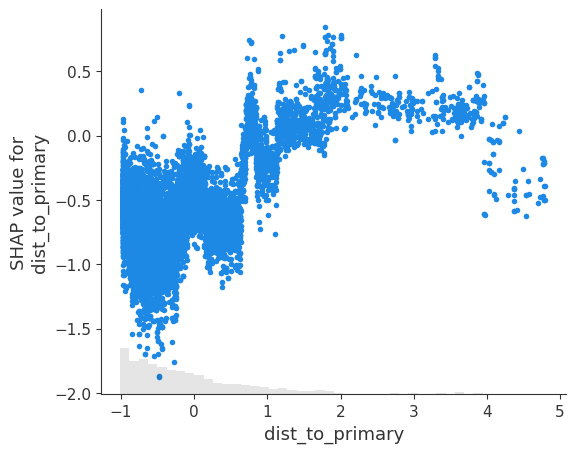

In [34]:
# Create DataFrames with column names
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Refit model with DataFrames
model.fit(X_train_df, y_train)

# SHAP explanation (using TreeExplainer for tree-based models instead of LinearExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_df)

# Visualise
print(shap_values.feature_names)

# Select class 0 (or whichever class you want to inspect)
shap.plots.scatter(shap_values[:, 1, 0])  # [:, feature, class]


Waterfall plots

A SHAP waterfall chart explains how the features of a single instance contribute to a specific model output (in classification: the log-odds or probability for one class).

data structure: (samples, classes, features)


**How to Read the Chart**
Base value (at the bottom):
The expected model output (log-odds) for class 0 over the entire dataset — the baseline prediction if no features were known.
Feature bars (middle):
Each feature either increases (red bars) or decreases (blue bars) the model’s output for class 0 relative to the base value.
Final value (at the top):
The model’s predicted log-odds for class 0 for this instance.


You’re seeing exactly why the model believed this penguin should (or shouldn’t) belong to class 0, and which features drove that decision.














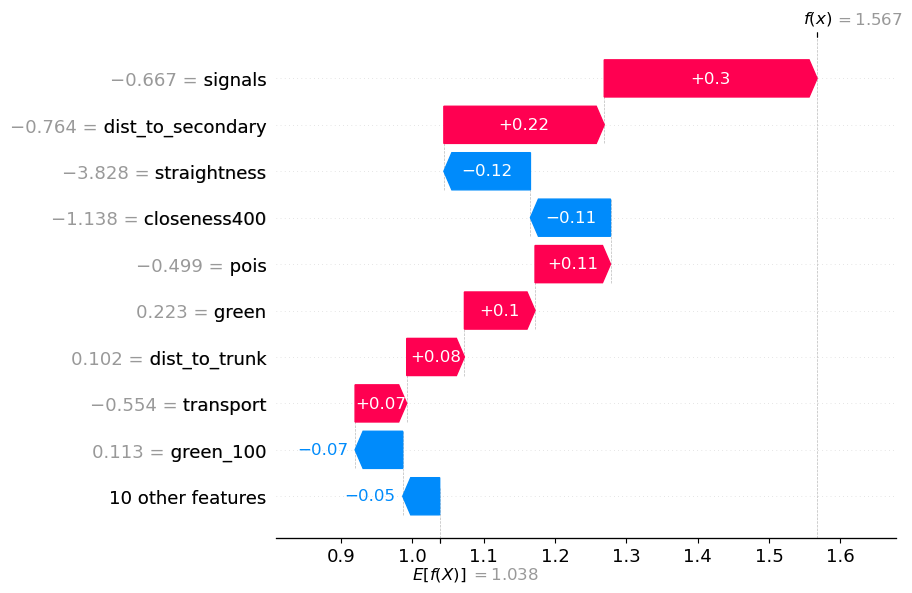

In [35]:
shap.plots.waterfall(shap_values[2][:, 2]) #  [sampleID][:, label]

Summary plot

The SHAP summary plot is a compact visualisation that summarises global feature importance and the distribution of feature effects across your dataset.

What the Bar Plot Shows
Each bar corresponds to a feature.

Bar length represents the mean absolute SHAP value for that feature across all samples.

This is a measure of overall feature importance: how much that feature contributes, on average, to the model’s output magnitude (regardless of direction).





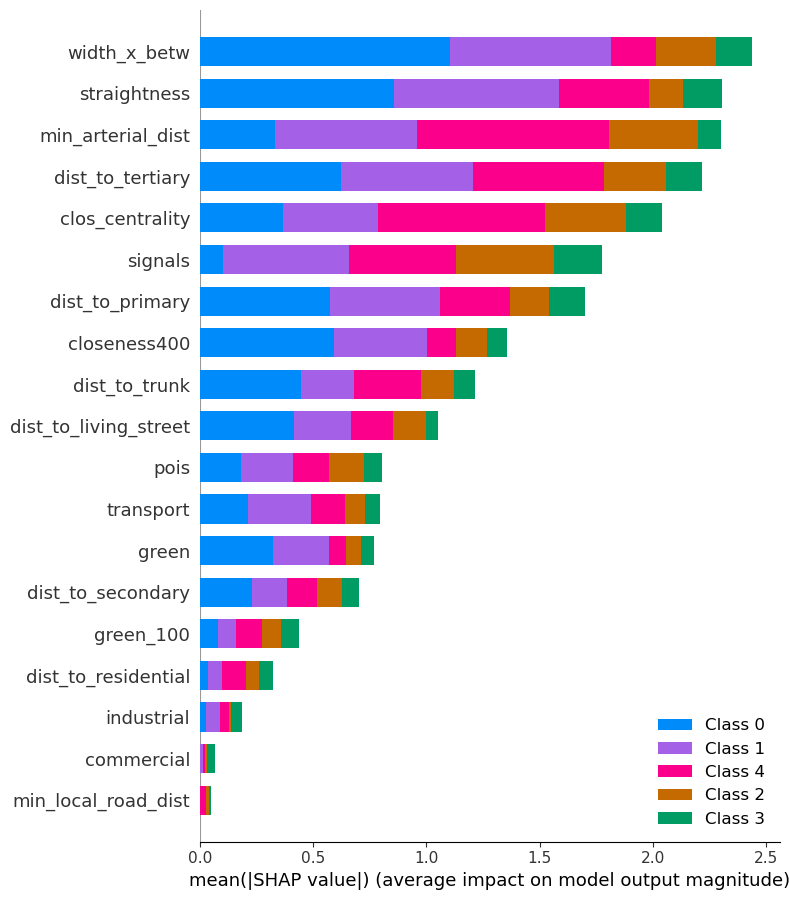

In [37]:
shap.summary_plot(shap_values, X_train_df)
